# 📁 Traffic sign recognition for autonomous vehicles, using deep learning

The objective of this project is to develop a traffic sign recognition system capable of accurately detecting and classifying road signs from images captured by onboard cameras.

This system contributes to:
- Safer autonomous driving
- Improved real-time navigation
- Reduced risk of traffic sign misinterpretation

By leveraging Deep Learning (CNN), the model learns to recognize 43 different types of traffic signs.

_____________________________________________________________________________________

# CONTEXT

Autonomous vehicles rely on real-time perception systems to safely navigate complex environments.
Traffic sign recognition is a critical component for interpreting road regulations and warnings.
This project develops a CNN-based model to accurately classify traffic signs from onboard camera images.
The system contributes to safer, more reliable, and efficient autonomous driving.

# DATA DESCRIPTION

We used the GTSRB – German Traffic Sign Recognition Benchmark dataset 


Dataset Characteristics:
- 43 traffic sign classes
- Thousands of labeled images
- Real-world variations (lighting, angle, scale)

Data Split:
- Training Set → Train.csv + images
- Testing Set → Test.csv + images
- Meta Set → Meta.csv (additional information)

Images were organized into structured subfolders for model training.

In [4]:
#---------------
#Import packages
#---------------
import kagglehub
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from PIL import Image
import shutil
from sklearn.metrics import classification_report
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from tensorflow.keras.optimizers import SGD
from keras.layers import Conv2D, Input, ZeroPadding2D, BatchNormalization, Activation, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1) Data import & Setup

In [5]:
#----------------
# Import the data
#----------------

# Download latest version of our dataset for Traffic Sign Recognition for Autonomous Vehicles
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign",)
print("Path to dataset files:", path)

# Path to the dataset
dataset_path = "/root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1"
print("Dataset contents:")
print(os.listdir(dataset_path))


# Load the CSV file train, meta & test
csv_path_train = os.path.join(dataset_path, 'Train.csv')  # Path to CSV file
train_data = pd.read_csv(csv_path_train)
print(train_data.head())
csv_path_meta = os.path.join(dataset_path, 'Meta.csv')  # Path to CSV file
meta_data = pd.read_csv(csv_path_meta)
print(meta_data.head())
csv_path_test = os.path.join(dataset_path, 'Test.csv')  # Path to CSV file
test_data = pd.read_csv(csv_path_test)
print(test_data.head())

# Uploading files (image)
train_images_path = os.path.join(dataset_path, 'Train')  # The folder with the training images
test_images_path = os.path.join(dataset_path, 'Test') # The folder with the test images
meta_images_path = os.path.join(dataset_path, 'Meta') # The folder with the metadata images

print("Train images folder contents:", os.listdir(train_images_path))
print("Test images folder contents:", os.listdir(test_images_path))
print("Meta images folder contents:", os.listdir(meta_images_path))

100%|██████████| 612M/612M [00:04<00:00, 154MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1
Dataset contents:
['Test', 'Train', 'train', 'Meta.csv', 'meta', 'Train.csv', 'test', 'Test.csv', 'Meta']
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     27      26       5       5      22      20       20   
1     28      27       5       6      23      22       20   
2     29      26       6       5      24      21       20   
3     28      27       5       6      23      22       20   
4     28      26       5       5      23      21       20   

                             Path  
0  Train/20/00020_00000_00000.png  
1  Train/20/00020_00000_00001.png  
2  Train/20/00020_00000_00002.png  
3  Train/20/00020_00000_00003.png  
4  Train/20/00020_00000_00004.png  
          Path  ClassId  ShapeId  ColorId SignId
0  Meta/27.png       27        0        0   1.32
1   Meta/0.png        0        1        0   3.29
2   Meta/1.png        1        1        0   3.29
3 

# 2) Data organization 

In [6]:
# Recreate a folder so that the images in the test folder are in subfolders
test_classes_dir = '/content/extracted_data/test_classes/'

# Create sub-folders for each class
for class_id in test_data['ClassId'].unique():
    class_dir = os.path.join(test_classes_dir, str(class_id))
    if not os.path.exists(class_dir):
        os.makedirs(class_dir)

# Move images to the appropriate sub-folders
for _, row in test_data.iterrows():
    image_path = row['Path']  # path to the image
    class_id = row['ClassId']  # Class identifier
    # Copy the image to the appropriate class folder
    src_path = os.path.join(dataset_path, image_path)
    dest_path = os.path.join(test_classes_dir, str(class_id), os.path.basename(image_path))
    shutil.copy(src_path, dest_path)

# Look at the number of images in the directories
print("Test directory contains:", len(os.listdir('/content/extracted_data/test_classes/')))
print("Train directory contains:", len(os.listdir(train_images_path)))

# Number of images per class
for class_id in test_data['ClassId'].unique():
    print(f"Images in class {class_id}: {len(os.listdir(f'/content/extracted_data/test_classes/{class_id}'))}")

class_ids = train_data['ClassId'].values  # Retrieve image ClassId
image_paths = train_data['Path'].values # Retrieve image paths

Test directory contains: 43
Train directory contains: 43
Images in class 16: 150
Images in class 1: 720
Images in class 38: 690
Images in class 33: 210
Images in class 11: 420
Images in class 18: 390
Images in class 12: 690
Images in class 25: 480
Images in class 35: 390
Images in class 7: 450
Images in class 23: 150
Images in class 4: 660
Images in class 9: 480
Images in class 21: 90
Images in class 20: 90
Images in class 27: 60
Images in class 3: 450
Images in class 13: 720
Images in class 10: 660
Images in class 5: 630
Images in class 17: 360
Images in class 34: 120
Images in class 2: 750
Images in class 8: 450
Images in class 30: 150
Images in class 24: 90
Images in class 15: 210
Images in class 26: 180
Images in class 28: 150
Images in class 22: 120
Images in class 14: 270
Images in class 32: 60
Images in class 29: 90
Images in class 6: 150
Images in class 36: 120
Images in class 40: 90
Images in class 41: 60
Images in class 31: 270
Images in class 19: 60
Images in class 0: 60
Ima

# 3) Image preprocessing & Data loading into generators

In [7]:
# Image pre-processing for training and testing
train_datagen = ImageDataGenerator(rescale=1./255,  # Pixel standardisation
                                   rotation_range=30,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   fill_mode='nearest')

test_datagen = ImageDataGenerator(rescale=1./255)  # Pixel normalisation for test data

# Define image generators for training and testing
train_generator = train_datagen.flow_from_directory(
    train_images_path,  # Training images folder
    target_size=(32, 32),  # Image size
    batch_size=32,
    class_mode='categorical')  # Classification multiple

validation_generator = test_datagen.flow_from_directory(
    test_classes_dir,  # Testing images folder
    target_size=(32, 32),  # Image size
    batch_size=32,
    class_mode='categorical')  #  Multiple classification

Found 39209 images belonging to 43 classes.
Found 12630 images belonging to 43 classes.


# 4) CNN model building + training

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 99s 79ms/step - accuracy: 0.1478 - loss: 3.1436 - val_accuracy: 0.3888 - val_loss: 1.8595
Epoch 2/30
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 97s 79ms/step - accuracy: 0.3475 - loss: 2.1349 - val_accuracy: 0.4995 - val_loss: 1.4996
Epoch 3/30
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 96s 78ms/step - accuracy: 0.4349 - loss: 1.7759 - val_accuracy: 0.5669 - val_loss: 1.3369
Epoch 4/30
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 96s 78ms/step - accuracy: 0.4833 - loss: 1.5896 - val_accuracy: 0.6042 - val_loss: 1.2130
Epoch 5/30
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 98s 80ms/step - accuracy: 0.5228 - loss: 1.4711 - val_accuracy: 0.6358 - val_loss: 1.1383
Epoch 6/30
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 96s 78ms/step - accuracy: 0.5526 - loss: 1.3521 - val_accuracy: 0.6510 - val_loss: 1.1216
Epoch 7/30
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 96s 78ms/step - accuracy: 0.5710 - loss: 1.3041 - val_accuracy: 0.6518 - val_loss: 1.1030
Epoch 8/30
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 98s 80ms/step - accuracy: 0.5933 -

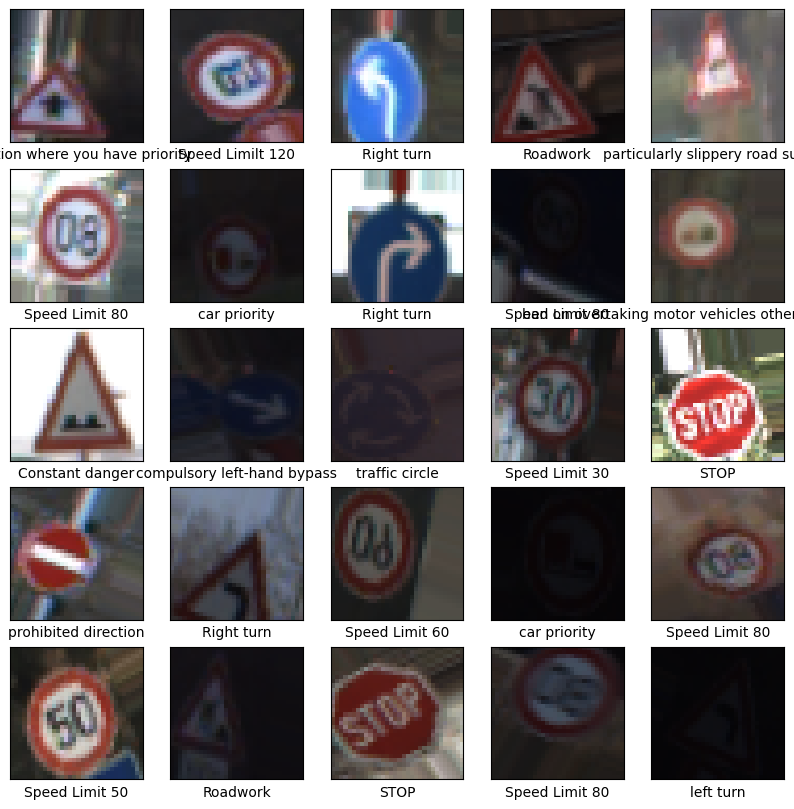

In [8]:
# Create a CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(train_generator.num_classes, activation='softmax')  # Nombre de classes basé sur ton dataset
])

# Compile model
model.compile(optimizer=tf.keras.optimizers.Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(train_generator, epochs=30, validation_data=validation_generator)

# Evaluate model performance
test_loss, test_acc = model.evaluate(validation_generator, verbose=2)
print("\nTest accuracy:", test_acc)

# Dictionary for class names
class_names = {
    0: 'Speed Limit 20',
    1: 'Speed Limit 30',
    2: 'car priority',
    3: 'Insertion where you have priority',
    4: 'Priority road',
    5: 'give way',
    6: 'STOP',
    7: 'prohibited to all motor vehicles',
    8: 'no trucks allowed',
    9: 'prohibited direction',
    10: 'hazard may or may not be specified',
    11: 'left turn',
    12: 'Speed Limit 50',
    13: 'Right turn',
    14: 'Succession of bends, the first of which is to the left',
    15: 'Constant danger',
    16: 'particularly slippery road surface',
    17: 'road narrowed to the right',
    18: 'Roadwork',
    19: 'Trafic light announcement',
    20: 'pedestrian crossing',
    21: 'Pedestrian Area',
    22: 'bicycle zone',
    23: 'Speed Limit 60',
    24: 'Risk of snow',
    25: 'passage of wild animals',
    26: 'end of intersection',
    27: 'Right turn',
    28: 'Left Turn',
    29: 'one way',
    30: 'mandatory direction at next intersection: straight ahead or right',
    31: 'mandatory direction at next intersection: straight ahead or left',
    32: 'compulsory right-hand bypass',
    33: 'compulsory left-hand bypass',
    34: 'Speed Limit 70',
    35: 'traffic circle',
    36: 'end of overtaking ban',
    37: 'end of overtaking ban for goods vehicles',
    38: 'Speed Limit 80',
    39: 'End of speed limit',
    40: 'Speed Limit 100',
    41: 'Speed Limilt 120',
    42: 'ban on overtaking motor vehicles other than 2-wheelers',
}


# Display of the first images in the dataset
plt.figure(figsize=(10, 10))

# Get a batch of images and labels
images, labels = next(train_generator)  # Use next() to obtain a batch

for i in range(25):  # Afficher les 25 premières images
    plt.subplot(5, 5, i + 1)
    plt.xticks([])  # Remove ticks from axes
    plt.yticks([])  # Remove ticks from axes
    plt.grid(False)  # No grid

    # Display the image
    plt.imshow(images[i])  # Display the first image in the batch
    label_index = labels[i].argmax()  # Use argmax() to obtain the class index
    plt.xlabel(class_names[label_index])  # Display the class name

# 5) Evaluation & Reporting

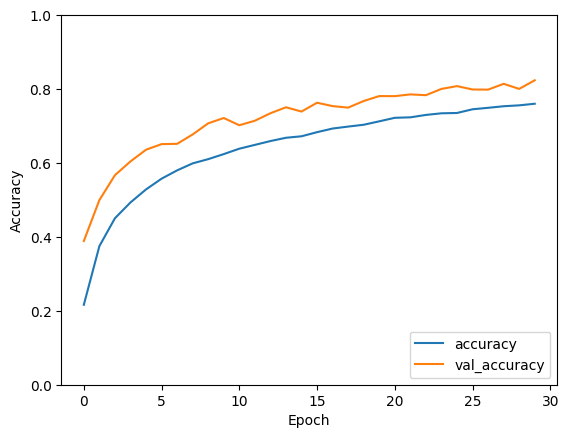

In [9]:
#------------------
#Prediction Accuray
#------------------

# Display precision
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

In [10]:
# ---------------------------------
# Precision/recall/F1-score/support
# ---------------------------------

# Predictions on the test dataset
predictions = model.predict(validation_generator, verbose=1)
y_pred = np.argmax(predictions, axis=1)

# Get the real labels
y_true = validation_generator.classes

# Display the classification report
print(classification_report(y_true, y_pred, target_names=validation_generator.class_indices))

395/395 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        60
           1       0.06      0.06      0.06       720
          10       0.05      0.05      0.05       660
          11       0.03      0.03      0.03       420
          12       0.05      0.05      0.05       690
          13       0.05      0.06      0.05       720
          14       0.02      0.02      0.02       270
          15       0.01      0.01      0.01       210
          16       0.01      0.01      0.01       150
          17       0.02      0.02      0.02       360
          18       0.03      0.03      0.03       390
          19       0.01      0.02      0.01        60
           2       0.07      0.08      0.07       750
          20       0.00      0.00      0.00        90
          21       0.00      0.00      0.00        90
          22       0.01      0.01      0.01       120
          23       0.01      0.01     

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Results & Recommendations

After we tested the Model on validation dataset. We analised the Performance evaluated using:
- Accuracy metric
- Classification Report (Precision, Recall, F1-score)

The CNN model was trained for 30 epochs and achieved an overall validation accuracy of approximately 82%.

Demonstrating solid performance in multi-class image classification. Training and validation curves indicate stable learning behavior.
Most misclassifications occur between visually similar traffic signs, such as speed limit variations or triangular warning signs, highlighting the challenge of fine-grained visual discrimination. 
To further improve performance, transfer learning approaches (e.g., MobileNetV2 or ResNet) could be implemented to enhance feature extraction, along with hyperparameter tuning and regularization techniques. 